In [ ]:
#test CFCNN on real bio data of chromatin - see https://www.science.org/doi/10.1126/sciadv.aaw0683
#load outputs that has been rendered from bio stack using different methods

import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
from scipy.stats import entropy
import h5py
from tqdm import tqdm

img_thst = np.load('thst_img.npy')
img_cnn = np.load('cfcnn_full_bio_out.npy')
img_decode = np.load('decode_bio_render.npy')

In [55]:
img_thst.shape, img_cnn.shape, img_decode.shape

((2048, 2048), (2048, 2048), (2048, 2048))

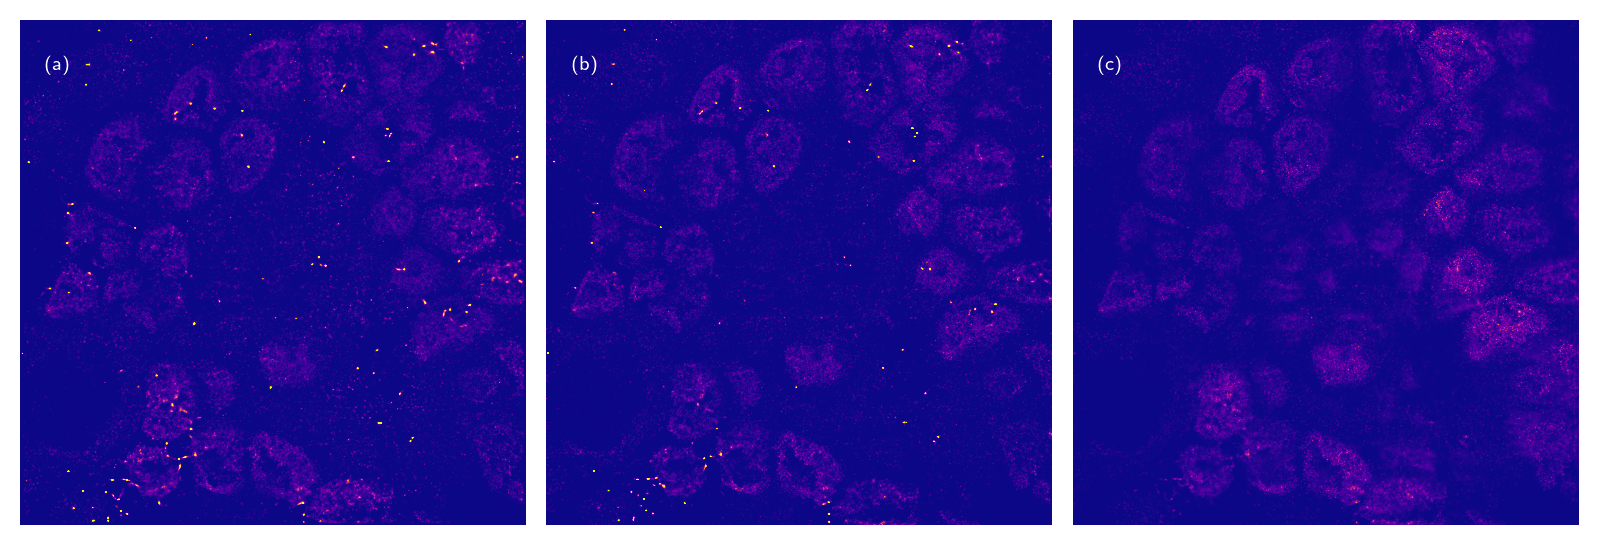

In [57]:
CMAP = 'plasma'
Q1 = 0.001
Q2 = 0.999
GAMMA = 0.8
BLUR = 4

def preprocess(img):
    nimg = ndi.gaussian_filter((img/np.max(img))**GAMMA, BLUR)
    vmin = np.quantile(img, Q1)
    vmax = np.quantile(img, Q2)
    return nimg, vmin, vmax

plt.rcParams.update({
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'axes.spines.right': True,
    'axes.spines.top': True,
    'xtick.bottom': True,
    'xtick.labelbottom': True,
    'ytick.left': True,
    'ytick.labelleft': True,
    'lines.linewidth': 1,
    'lines.markersize': 4,
    'font.size': 7,
    'text.usetex': True,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
})

fig, ax = plt.subplots(1,3,figsize=(8,3), dpi=200)
labs = 'abc'

for axi, _img, label in zip(ax, (img_thst, img_decode, img_cnn), labs):
    processed_img, vmn, vmx = preprocess(_img)
    axi.imshow(_img, vmin=vmn, vmax=vmx, cmap=CMAP)
    axi.set_axis_off()
    axi.text(0.05, 0.9, f'({label})', c='w', transform=axi.transAxes)
plt.tight_layout()
fig.savefig('bio_figure.pdf')
plt.show()